In [1]:
import torch
import math
import numpy as np
from protocolopt.potentials import GeneralCoupledPotential
from protocolopt.potentials.quartic import QFP_Potential
# from protocolopt.types import StateSpace, ControlVector
from protocolopt.protocols import LinearPiecewise
from protocolopt.simulators import EulerMaruyama
from protocolopt.losses import StandardLogicGateLoss
from protocolopt import ProtocolOptimizer
from protocolopt.sampling import ConditionalFlow, LaplaceApproximation
from protocolopt.callbacks import TrajectoryPlotCallback, ConfusionMatrixCallback, PotentialLandscapePlotCallback, ProtocolPlotCallback
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML

/Users/tkwtang/protocolopt/.pixi/envs/default/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
try:
    from protocolopt.callbacks import AimCallback
    AIM_AVAILABLE = True
except ImportError:
    AIM_AVAILABLE = False
    print("Aim not available - skipping experiment tracking")

# Device configuration
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available() and torch.backends.mps.is_built():
    device = torch.device('mps')
else:
    device = torch.device('cpu')

print(f"Using device: {device}")

Using device: mps


# physical parameters

In [3]:
k_B, h_bar, PHI_0 = 1.380649e-23, 1.054571817e-34, 2.067833831e-15

R, L, C = 100, 5e-12, 1e-12  # ohm, H, F
T = 4.2  # K
k_BT = k_B * T

# constant factor
t_duration = 50

# t_c = t_duration * np.sqrt(L * C)

m_c = C
x_c = PHI_0 / (2 * np.pi)  # Convert to appropriate units
t_c = float(np.sqrt(m_c * x_c**2/k_BT))

v_c = x_c / t_c
nu_c = 1/R

# non-dimensional parameters
nu_1, nu_2 = 2, 1/2
m_1 = 1


# U_0 = float(m_c * x_c**2 / t_c**2 / k_BT) # in units of kBT
U_0 = float(x_c**2 / L / k_BT) # in units of kBT
# U_0 = 1.0


In [4]:
gamma = (nu_c * t_c / m_c) * nu_1
print(gamma)
print(U_0)

0.8643695857733819
373.5673904050238


5000

In [ ]:
# ProtocolOptimizer parameters
# time_steps = 1000
time_steps = 1000
dt = 1/time_steps
# gamma = 0.1
gamma = (nu_c * t_c / m_c) * nu_1
# gamma = 10 

beta = U_0
beta = m_c * v_c**2 / k_BT
mass = m_1
# Protocol parameters
num_coefficients = 16
a_endpoints = [0.0, 0.0]
b_endpoints = [np.pi, np.pi]

# Training parameters
samples_per_well = 2000 
training_iterations = 400
learning_rate = 0.25
alpha = 2.0  # endpoint_weight
alpha_1 = 0.1  # var_weight
alpha_2 = 1.0  # work_weight
alpha_3 = 5e-4  # smoothness_weight

# Additional parameters
spatial_dimensions = 1
mcmc_warmup_ratio = 0.1
mcmc_starting_spatial_bounds = torch.tensor([[-4.0, 4.0]], device=device)

# Calculate centers
centers = 2.04

# Create endpoints tensor
endpoints = torch.tensor([
    [a_endpoints[0], a_endpoints[1]], 
    [b_endpoints[0], b_endpoints[1]]
], device=device)

# Create initial coefficient guess
initial_coeff_guess = 0.1*torch.randn((2, num_coefficients), device=device)

In [21]:
# Instantiate Protocol (LinearPiecewise)
protocol = LinearPiecewise(
    control_dim=2,
    time_steps=time_steps,
    knot_count=num_coefficients+2,
    initial_coeff_guess=initial_coeff_guess,
    endpoints=endpoints
)

# Instantiate Potential (GeneralCoupledPotential)
potential = QFP_Potential(compile_mode=True, U_0=U_0)

# Instantiate Simulator (EulerMaruyama)
simulator = EulerMaruyama(
    mode='underdamped',
    gamma=gamma,
    beta=beta,
    mass=mass,
    dt=dt,
    compile_mode=True
)

# Create loss function (StandardLogicGateLoss)
midpoints = torch.tensor([0.0], device=device)
bit_locations = torch.tensor([[-centers], [centers]], device=device)
truth_table = {0: ['1'], 1: ['0']}

loss = StandardLogicGateLoss(
    midpoints=midpoints,
    truth_table=truth_table,
    bit_locations=bit_locations,
    endpoint_weight=alpha,
    work_weight=alpha_2,
    var_weight=alpha_1,
    smoothness_weight=alpha_3,
    exponent=2
)

2026-01-15 15:36:20,545 - protocolopt - INFO - Mac detected: Skipping torch.compile to avoid compiler dependency issues.
2026-01-15 15:36:20,546 - protocolopt - INFO - Mac detected: Skipping torch.compile to avoid compiler dependency issues.


In [22]:

# Create callbacks
callbacks = []

# Add plotting callbacks
trajectory_callback = TrajectoryPlotCallback(
    save_dir='figs',
    plot_frequency=None,
    num_trajectories=100
)
callbacks.append(trajectory_callback)

confusion_matrix_callback = ConfusionMatrixCallback(
    save_dir='figs',
    plot_frequency=None
)
callbacks.append(confusion_matrix_callback)

potential_landscape_callback = PotentialLandscapePlotCallback(
    save_dir='figs',
    plot_frequency=None
)
callbacks.append(potential_landscape_callback)

coefficient_callback = ProtocolPlotCallback(
    save_dir='figs',
    plot_frequency=None
)

callbacks.append(coefficient_callback)

# IMPORTANT: AimCallback must be last
# Add Aim callback if available
if AIM_AVAILABLE:
    aim_callback = AimCallback(
        experiment_name='bitflip_training',
        log_system_params=False
    )
    callbacks.append(aim_callback)

In [23]:
num_samples = samples_per_well * (2**spatial_dimensions)

init_cond_generator = LaplaceApproximation(
    dt=dt,
    gamma=gamma,
    mass=mass,
    centers=bit_locations,
    device=device,
    beta=beta,
    spatial_dimensions=spatial_dimensions,
    time_steps=time_steps,
    # energy_factor=U_0,
    num_samples=num_samples
)

# simulation

In [24]:

# U_0 = 1.0

initial_pos, initial_vel, noise = init_cond_generator.generate_initial_conditions(potential=potential, protocol=protocol, loss=loss)
# initial_pos = 
# initial_vel = initial_vel.detach().cpu().numpy()


Solving landscape for Laplace approximation...
Landscape solved


Text(0.5, 1.0, 'Initial Kinetic Energy: 0.5044 kBT')

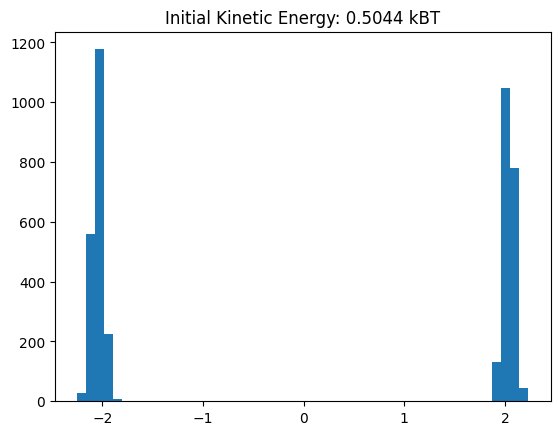

In [25]:


init_hist_plot = plt.hist(initial_pos.detach().cpu().numpy(), bins = 50)
init_KE = 0.5 * mass * torch.mean(initial_vel**2, dim=0)
plt.title(f'Initial Kinetic Energy: {init_KE.item():.4f} kBT')

In [26]:
protocol_tensor = protocol.get_protocol_tensor()
modified_protocol_tensor = protocol_tensor.clone()
modified_protocol_tensor[0, :] = 0
# modified_protocol_tensor[1, :] = 0
modified_protocol_tensor[1, :] = torch.linspace(0, np.pi, modified_protocol_tensor[1, :].shape[0], device = device)

modified_noise = noise * torch.tensor(0, device=device)

modified_initial_vel = initial_vel * torch.tensor(0, device=device)


protocol_tensor_used = modified_protocol_tensor
noise_used = modified_noise
initial_vel_used = initial_vel

all_states, potential_values, malliavin_weights = simulator.make_microstate_paths(potential=potential, initial_pos=initial_pos, initial_vel=initial_vel_used, time_steps=time_steps, noise=noise_used, protocol_tensor=protocol_tensor_used)
all_states = all_states.detach().cpu().numpy()

2026-01-15 15:36:30,297 - protocolopt - INFO - Mac detected: Skipping torch.compile to avoid compiler dependency issues.
2026-01-15 15:36:30,297 - protocolopt - INFO - Mac detected: Skipping torch.compile to avoid compiler dependency issues.


In [27]:
# protocol_tensor = protocol.get_protocol_tensor().detach().cpu().numpy()

In [28]:




state_t_0 = all_states[:, 0, 0, 0]
x_array = torch.linspace(-4, 4, 50, device=device).reshape(-1, 1)
x_bin = np.linspace(-4, 4, 200)
potential_at_t_0 = potential.potential_value(x_array, protocol_tensor_used[:, 0]) 


In [32]:

fig, ax = plt.subplots()

pdf_ax = ax.twinx()

# U_0 = 1

potential_at_t_0 = potential.potential_value(x_array, protocol_tensor_used[:, 0]).detach().cpu().numpy()
potential_shift = min(potential_at_t_0)
ax.plot(x_array.detach().cpu().numpy(), potential_at_t_0 - potential_shift, color='red')
pdf_ax.hist(state_t_0, bins = x_bin)
pdf_ax.get_yaxis().set_visible(False)

def update(i):
    # for each frame, update the data stored on each artist.
    ax.clear()
    pdf_ax.clear()
    ax.set_ylabel('Potential')
    new_data = all_states[:, 0, i, 0]
    potential_at_t_i = potential.potential_value(x_array, protocol_tensor_used[:, i])
    ax.plot(x_array.detach().cpu().numpy(), potential_at_t_i.detach().cpu().numpy() - potential_shift, color='red')
    pdf_ax.hist(new_data, bins = x_bin)

animation_frames = time_steps
animation_frames = range(0, time_steps, 50)
ani = animation.FuncAnimation(fig, update, frames=animation_frames, interval = 50)
# ani = animation.FuncAnimation(fig=fig, func=update, frames=time_steps, interval=30)
plt.close()
# HTML(ani.to_jshtml())
HTML(ani.to_html5_video())


2026-01-15 15:39:21,388 - matplotlib.animation - INFO - Animation.save using <class 'matplotlib.animation.FFMpegWriter'>
2026-01-15 15:39:21,389 - matplotlib.animation - INFO - MovieWriter._run: running command: ffmpeg -f rawvideo -vcodec rawvideo -s 640x480 -pix_fmt rgba -framerate 20.0 -loglevel error -i pipe: -vcodec h264 -pix_fmt yuv420p -y /var/folders/lg/s5mcr4vx5p76ymtpjnvb304m0000gq/T/tmpwi1ckkve/temp.m4v


In [33]:
potential.get_potential_value

<bound method Potential.get_potential_value of <protocolopt.potentials.quartic.QFP_Potential object at 0x31ec3ac90>>

In [34]:
average_KE = torch.mean(1/2 * mass * initial_vel**2)
print(average_KE)

tensor(0.5044, device='mps:0')


(array([  1.,   0.,   1.,   1.,   0.,   2.,   0.,   1.,   1.,   0.,   2.,
          2.,   7.,   5.,   3.,   2.,   7.,   7.,  10.,  19.,  16.,  23.,
         22.,  16.,  30.,  34.,  35.,  38.,  36.,  70.,  60.,  55.,  54.,
         67.,  91.,  75.,  81.,  80.,  96.,  99., 110., 104., 112., 114.,
         99., 123., 123., 131., 125., 122., 131., 115., 113.,  95.,  97.,
         93.,  99., 104.,  88.,  71.,  71.,  62.,  63.,  51.,  55.,  41.,
         45.,  46.,  35.,  26.,  21.,  25.,  23.,  17.,  13.,  12.,  13.,
         10.,  11.,  13.,   4.,   1.,   5.,   2.,   2.,   5.,   1.,   2.,
          0.,   3.,   2.,   0.,   1.,   0.,   0.,   0.,   0.,   0.,   0.,
          1.]),
 array([-5.39287498e-07, -5.27911027e-07, -5.16534556e-07, -5.05158141e-07,
        -4.93781670e-07, -4.82405198e-07, -4.71028727e-07, -4.59652284e-07,
        -4.48275813e-07, -4.36899370e-07, -4.25522899e-07, -4.14146427e-07,
        -4.02769984e-07, -3.91393542e-07, -3.80017070e-07, -3.68640599e-07,
        -3.572

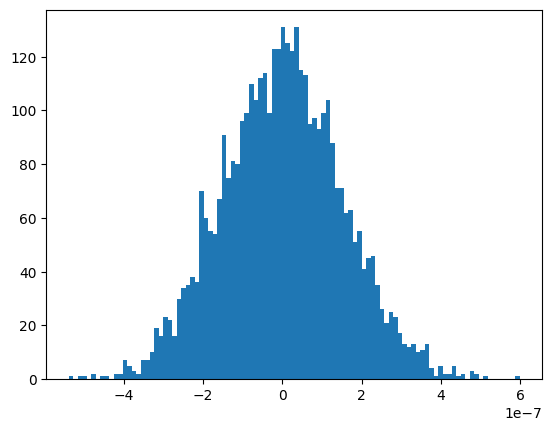

In [150]:

plt.hist(v_c * initial_vel.cpu().detach(), bins=100)

In [151]:
average_KE

tensor(0.0013, device='mps:0')

In [152]:
torch.mean(1/2 * mass * initial_vel**2)

tensor(0.0013, device='mps:0')

In [160]:
uid = "ba7e2d34-eff1-11f0-9781-4a4cfa5cdcfe"
uid = "996a525a-f003-11f0-983c-4a4cfa5cdcfe"
# uid = "9a0f250c-f00b-11f0-b488-4a4cfa5cdcfe"
microstate_paths_load = torch.load(f"sim_data/{uid}_microstate_paths.pt").detach().cpu().numpy()
potential_val_load = torch.load(f"sim_data/{uid}_potential_val.pt")
protocol_tensor_load = torch.load(f"sim_data/{uid}_protocol_tensor.pt")

# constant factor
t_duration = 6
t_c = t_duration * np.sqrt(L * C)
v_c = x_c / t_c

In [161]:
fig, ax = plt.subplots()
pdf_ax = ax.twinx()

x_array = torch.linspace(-4, 4, 50, device=device).reshape(-1, 1)
potential_at_t_0 = potential.get_potential_value(x_array, protocol_tensor_load, 0)
bins = np.linspace(-4, 4, 200)
# ax.plot(x_array.detach().cpu().numpy(), potential_at_t_0.detach().cpu().numpy() * U_0, color='red')
pdf_ax.hist(microstate_paths_load[:, 0, 0, 0], bins = bins)
pdf_ax.get_yaxis().set_visible(False)
pdf_ax.set_xlim(-4, 4)

def update(i):
    # for each frame, update the data stored on each artist.
    ax.clear()
    pdf_ax.clear()
    # ax.set_ylabel('Potential (k_BT)')
    new_data = microstate_paths_load[:, 0, i, 0]
    potential_at_t_i = potential.get_potential_value(x_array, protocol_tensor_load, i)
    # print(potential_at_t_i)
    # ax.plot(x_array.detach().cpu().numpy(), potential_at_t_i.detach().cpu().numpy() * U_0, color='red')
    pdf_ax.hist(new_data, bins = bins)

# animation_frames = microstate_paths_load.shape[2]-1
animation_frames = range(0, microstate_paths_load.shape[2]-1, 5)
ani = animation.FuncAnimation(fig, update, frames=animation_frames, interval = 50)
# ani = animation.FuncAnimation(fig=fig, func=update, frames=time_steps, interval=30)
plt.close()
# # HTML(ani.to_jshtml())
HTML(ani.to_html5_video())

2026-01-15 13:22:35,594 - matplotlib.animation - INFO - Animation.save using <class 'matplotlib.animation.FFMpegWriter'>
2026-01-15 13:22:35,595 - matplotlib.animation - INFO - MovieWriter._run: running command: ffmpeg -f rawvideo -vcodec rawvideo -s 640x480 -pix_fmt rgba -framerate 20.0 -loglevel error -i pipe: -vcodec h264 -pix_fmt yuv420p -y /var/folders/lg/s5mcr4vx5p76ymtpjnvb304m0000gq/T/tmpmrxjchji/temp.m4v


# no potential

In [157]:
fig, ax = plt.subplots()

x_array = torch.linspace(-4, 4, 50, device=device).reshape(-1, 1)

bins = np.linspace(-4, 4, 200)

ax.hist(microstate_paths_load[:, 0, 0, 0], bins = bins)
ax.set_xlim(-4, 4)
ax.set_ylim(0, 2000)
ax.set_title("new Langevin")

def update(i):
    # for each frame, update the data stored on each artist.
    ax.clear()
    # ax.set_ylabel('Potential (k_BT)')
    new_data = microstate_paths_load[:, 0, i, 0]
    
    ax.set_xlim(-4, 4)
    ax.set_ylim(0, 2000)
    ax.set_title("new Langevin")
    ax.hist(new_data, bins = bins)

# animation_frames = microstate_paths_load.shape[2]-1

animation_frames = range(0, microstate_paths_load.shape[2]-1, 5)
ani = animation.FuncAnimation(fig, update, frames=animation_frames, interval = 50)
# ani = animation.FuncAnimation(fig=fig, func=update, frames=time_steps, interval=30)
plt.close()
# # HTML(ani.to_jshtml())
HTML(ani.to_html5_video())

2026-01-15 13:15:49,666 - matplotlib.animation - INFO - Animation.save using <class 'matplotlib.animation.FFMpegWriter'>
2026-01-15 13:15:49,666 - matplotlib.animation - INFO - MovieWriter._run: running command: ffmpeg -f rawvideo -vcodec rawvideo -s 640x480 -pix_fmt rgba -framerate 20.0 -loglevel error -i pipe: -vcodec h264 -pix_fmt yuv420p -y /var/folders/lg/s5mcr4vx5p76ymtpjnvb304m0000gq/T/tmpla3qcgwf/temp.m4v


In [164]:
np.mean(1/2 * mass * microstate_paths_load[:, 0, 0, 1]**2) * m_c * v_c**2 / k_BT

np.float64(0.01383151548536025)

In [162]:
np.mean(1/2 * mass * microstate_paths_load[:, 0, 0, 1]**2) * U_0

np.float32(0.49793455)

In [110]:
KE_array = 1/2 * mass * microstate_paths_load[:, 0, :, 1]**2 * U_0
PE_array = potential_val_load.detach().cpu().numpy() * U_0
total_energy_array = KE_array[:, 1:] + PE_array

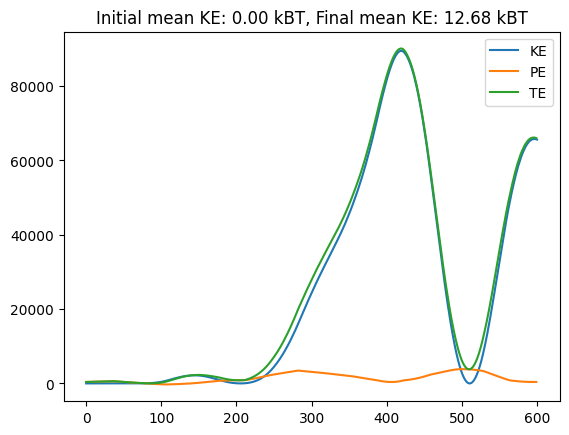

In [133]:
chosen_trajectory = 8
plt.plot(KE_array[chosen_trajectory, :], label='KE')
plt.plot(PE_array[chosen_trajectory, :], label='PE')
plt.plot(total_energy_array[chosen_trajectory, :], label='TE')
initial_mean_KE  = np.mean(1/2 * mass * microstate_paths_load[:, 0, 0, 1]**2) * m_c * v_c**2 / k_BT
final_mean_KE = np.mean(1/2 * mass * microstate_paths_load[:, 0, -1, 1]**2) * m_c * v_c**2 / k_BT
plt.title(f"Initial mean KE: {initial_mean_KE:.2f} kBT, Final mean KE: {final_mean_KE:.2f} kBT")
plt.legend()

In [97]:
KE_array

array([[2.57212937e-01, 1.95550635e-01, 1.22564815e-01, ...,
        2.87158356e+02, 2.86963287e+02, 2.88371429e+02],
       [7.68189549e-01, 6.25469446e-01, 4.40019935e-01, ...,
        3.49869568e+02, 3.52061615e+02, 3.52918518e+02],
       [7.65416682e-01, 7.40731597e-01, 7.66693771e-01, ...,
        6.36554141e+04, 6.36726562e+04, 6.36600000e+04],
       ...,
       [2.98399836e-01, 2.77863503e-01, 2.46293262e-01, ...,
        2.34057419e+02, 2.34824524e+02, 2.33937607e+02],
       [4.29016709e-01, 5.86700976e-01, 7.53500283e-01, ...,
        6.19042812e+04, 6.19152930e+04, 6.19328828e+04],
       [2.33334556e-01, 3.18737090e-01, 3.40468496e-01, ...,
        4.67305023e+02, 4.69344482e+02, 4.72252686e+02]],
      shape=(4000, 601), dtype=float32)